# Support Vector Machines

## Mushroom Dataset

#### Final Project: DSC 345/445

#### Victoria Burke and Rebecca Henzig


One of the machine learning algorithms we chose was Support Vector Machines, a supervised learning model that finds the best decision boundary that separates both classes (edible vs poisonous). We chose to train an SVM model because our data is completely categorical and binary, which is what SVM handles well.

To prepare the data, we used One-Hot Encoding to convert the categorical features into binary columns and used the StandardScaler to encode the features to have unit variance. We also used an 80-20 split for the train and test sets.

## Data Preparation

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('../data/cleaned_mushrooms.csv')

# train test split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 123, stratify = y
)

# One-hot encoding
cat_cols = X.columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

To find the optimal kernel for SVM, we tested RBF, Linear, Polynomial, and Sigmoid functions to map the original feature space into a higher-dimensional space where the data can be separated more easily.

 We used the default value of 1.0 for C as a baseline, and fit the model on the training data.



## Testing Kernels

In [30]:
# RBF vs Linear vs Polynomial vs Sigmoid

results = []

for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    svm_model = Pipeline( steps = [
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean = False)),
        ("classifier", SVC(kernel = kernel, C = 1, gamma = "scale", random_state = 123))
    ])
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        "Kernel": kernel,
        "Accuracy": accuracy,
        "Precision": report['weighted avg']['precision'],
        "Recall": report['weighted avg']['recall'],
        "F1-Score": report['weighted avg']['f1-score']
    })

results_df = pd.DataFrame(results)
results_df


,Kernel,Accuracy,Precision,Recall,F1-Score
0,linear,1.000000,1.000000,1.000000,1.000000
1,rbf,0.998769,0.998772,0.998769,0.998769
2,poly,0.998769,0.998772,0.998769,0.998769
3,sigmoid,0.987692,0.987706,0.987692,0.987693


In [31]:
for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_df[col] = results_df[col].round(4)

results_df

,Kernel,Accuracy,Precision,Recall,F1-Score
0,linear,1.0000,1.0000,1.0000,1.0000
1,rbf,0.9988,0.9988,0.9988,0.9988
2,poly,0.9988,0.9988,0.9988,0.9988
3,sigmoid,0.9877,0.9877,0.9877,0.9877


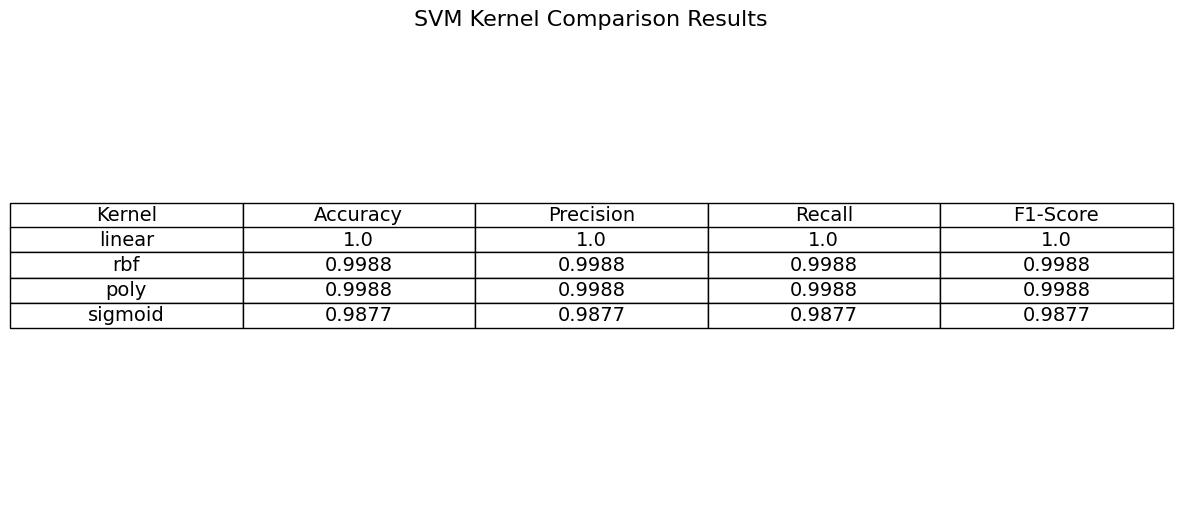

In [32]:
import os

fig, ax = plt.subplots(figsize = (10, 6))
ax.axis("off")
table = ax.table(
    cellText = results_df.values,
    colLabels = results_df.columns,
    cellLoc = "center",
    loc = "center"
)
table.set_fontsize(14)
table.scale(1.5, 1.5)
plt.title("SVM Kernel Comparison Results", fontsize = 16)
plt.savefig('../results/svm_kernel_comparison.png', bbox_inches = 'tight')
plt.show()


## Confusion Matrix

Confusion matrices were created for each kernel, to help visualize the performance on the data.

Text(0.5, 1.0, 'Confusion Matrix: RBF')

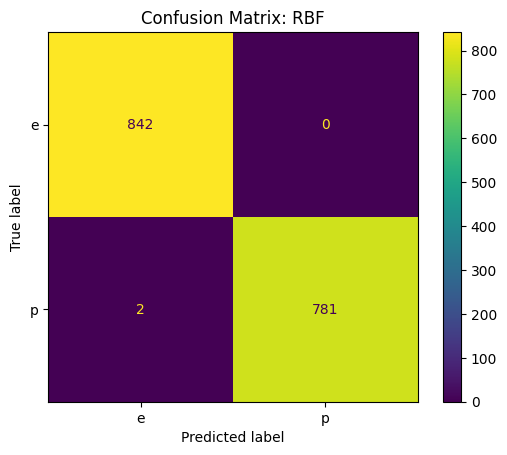

In [33]:
# Confusion Matrix for RBF Kernel
from sklearn.metrics import ConfusionMatrixDisplay


svm_rbf = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean = False)),
    ("classifier", SVC(kernel = "rbf", C = 1, gamma = "scale", random_state = 123))
])
svm_rbf.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(svm_rbf, X_test, y_test)
plt.title("Confusion Matrix: RBF")
#plt.show()

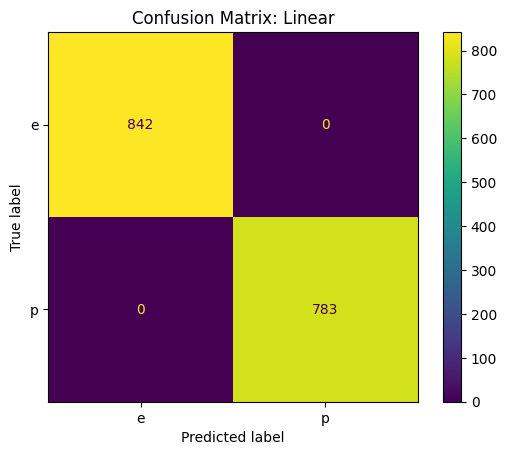

In [34]:
svm_linear = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean = False)),
    ("classifier", SVC(kernel = "linear", C = 1, random_state = 123))
])
svm_linear.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(svm_linear, X_test, y_test)
plt.title("Confusion Matrix: Linear")
#plt.show()
plt.savefig('../results/svm_linear.png', bbox_inches = 'tight')


#best confusion matrix

Text(0.5, 1.0, 'Confusion Matrix: Polynomial')

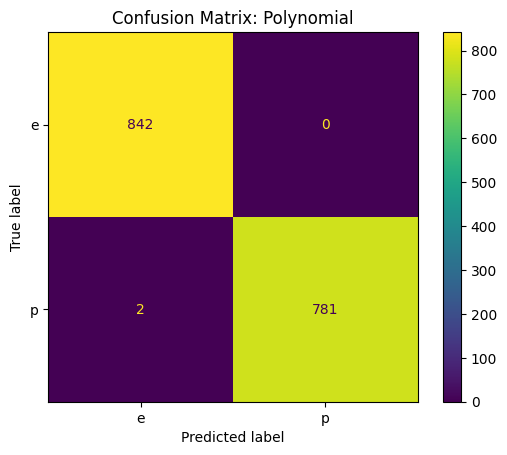

In [35]:
svm_poly = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean = False)),
    ("classifier", SVC(kernel = "poly", C = 1, degree = 3, random_state = 123))
])
svm_poly.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(svm_poly, X_test, y_test)
plt.title("Confusion Matrix: Polynomial")
#plt.show()

Text(0.5, 1.0, 'Confusion Matrix: Sigmoid')

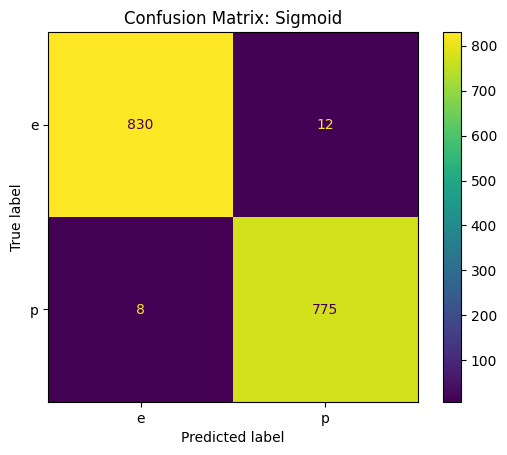

In [36]:
svm_sigmoid = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean = False)),
    ("classifier", SVC(kernel = "sigmoid", C = 1, gamma = "scale", random_state = 123))
])
svm_sigmoid.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(svm_sigmoid, X_test, y_test)
plt.title("Confusion Matrix: Sigmoid")
#plt.show()

## Grid Search

To verify the best value for C, we used Grid Search with 5 fold cross validation, instead of manually checking each value. This split up the training data into 5 folds, training 4 of the folds and validating with the 5th for each C value. The Grid Search returned that a value of C=0.1 was optimal for this dataset. 

We also decided to score of F1 rather than accuracy, because for this specific data, it is more dangerous to predict false negatives and we wanted to balance precision and recall.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Select the best kernel based on accuracy

best_kernel = results_df.loc[results_df['Accuracy'].idxmax(), 'Kernel']
print("Best kernel: ", best_kernel)

svm_grid_model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean = False)),
    ("classifier", SVC(kernel = best_kernel, random_state = 123))
])

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}
if best_kernel != "linear":
    param_grid["classifier__gamma"] = ["scale", "auto"]

grid_search = GridSearchCV(
    svm_grid_model,
    param_grid,
    cv = 5,
    scoring = "f1_weighted",
    verbose = 1
)
grid_search.fit(X_train, y_train)
print("Best params: ", grid_search.best_params_)
print("Best CV score: ", grid_search.best_score_)
print("Test score: ", grid_search.score(X_test, y_test))


Best kernel:  linear
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params:  {'classifier__C': 0.1}
Best CV score:  0.9998460310261729
Test score:  1.0


## Test and Evaluate

accuracy:  1.0
classification report: 
               precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



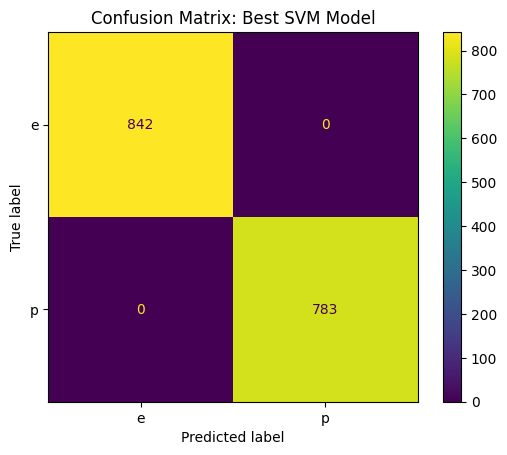

In [38]:
# Evaluate the best model on the test set

y_pred_best = grid_search.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred_best))
print("classification report: \n", classification_report(y_test, y_pred_best))

ConfusionMatrixDisplay.from_estimator(grid_search, X_test, y_test)
plt.title("Confusion Matrix: Best SVM Model")
plt.savefig('../results/svm_best_model.png', bbox_inches = 'tight')
plt.show()



In [39]:
# Support vector count

best_svm = grid_search.best_estimator_.named_steps['classifier']
print("Number of support vectors for each class: ", best_svm.n_support_)

Number of support vectors for each class:  [108  74]


## Hinge Loss

In [40]:
# Hinge Loss

from sklearn.metrics import hinge_loss

decision_scores = grid_search.decision_function(X_test)
loss = hinge_loss(y_test, decision_scores)
print("Hinge Loss: ", loss)

final = pd.DataFrame([{
    'model': 'SVM',
    'best_kernel': best_kernel,
    'best_C': grid_search.best_params_['classifier__C'],
    'cv_f1': grid_search.best_score_,
    'test_accuracy': accuracy_score(y_test, y_pred_best),
    'test_f1': classification_report(y_test, y_pred_best, output_dict=True)['weighted avg']['f1-score'],
    'hinge_loss': loss
}])

final.to_csv('../results/svm_results.csv', index=False)

Hinge Loss:  1.0839032841922028e-05


## Results

The SVM acheived perfect classification performance on the test set, with a test accuracy and weighted F1 score of 1.0. Grid Search identified the linear kernels as the best performing kernel, with the optimal regularization parameter of C = 0.1. The cross-validated F1 score confirms that this performance generalizes consistently across folds and is not a product of overfitting. The hinge loss further confirmed that correct predictions were made with high confidence. The success of a linear kernel with low regularization suggests that the edible and poisonous classes are linearly separable.